# Quantum Harmonic Oscillator PINN Tutorial

> **Model**: GaussianEnvelopePINN — hard Gaussian-envelope ansatz for the time-independent Schrödinger equation  
> **Problem class**: TISE eigenvalue problem — quantum harmonic oscillator ground state and excited states $n = 0, 1, 2, 3$  
> **Framing**: This notebook presents the quantum harmonic oscillator as a precision benchmark for physics-informed neural networks, with emphasis on eigenvalue recovery, wavefunction fidelity, and physically interpretable error analysis.

## Abstract

This notebook studies the one-dimensional quantum harmonic oscillator as a canonical eigenvalue benchmark for physics-informed neural networks. The objective is to recover a normalized wavefunction $\psi(x)$ and scalar energy $E$ such that

$$\hat{H}\psi(x) = E\psi(x), \qquad \hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2,$$

without supervised wavefunction labels. The implementation combines a hard Gaussian-envelope ansatz, low-discrepancy Sobol collocation, explicit even-parity regularization for the ground state, Rayleigh-consistent energy stabilization, and a two-stage optimizer consisting of AdamW followed by L-BFGS refinement. Under this formulation, the notebook attains **1.56934e-3 relative $L^2$ error**, **1.25322e-3 $L^\infty$ error**, and predicts the ground-state energy as **0.50001526**, only **1.52588e-5** away from the analytic value. The resulting fidelity is **0.99999754**, while the Rayleigh-consistency gap is **3.59893e-6**, indicating that the learned solution is accurate both as a function approximation and as a Hamiltonian eigenstate.

## 1. Introduction

The quantum harmonic oscillator (QHO) is a standard reference problem in quantum mechanics because the exact spectrum, exact eigenfunctions, parity structure, and uncertainty relations are all known in closed form. As a consequence, it provides an analytically sharp testbed for assessing whether a physics-informed neural network recovers not only the qualitative structure of a wavefunction but also the correct quantitative eigenvalue relation.

The present notebook treats the QHO as a constrained inverse problem. Rather than fitting labeled wavefunctions, the network is required to satisfy the time-independent Schrödinger equation, normalization, and symmetry constraints directly. This setting is especially suitable for evaluating whether a PINN can serve as a physically meaningful eigenvalue solver rather than merely a smooth function approximator.

The principal result reported here is a high-accuracy ground-state solution with **1.56934e-3 relative $L^2$ error**, **1.25322e-3 $L^\infty$ error**, and a learned energy of **0.50001526** against the exact value **0.50000000**. In addition, the small Rayleigh-consistency gap establishes that the learned scalar energy is consistent with the Hamiltonian expectation value of the predicted wavefunction.

## 2. Contributions

The notebook makes the following technical contributions.

| Contribution | Technical significance |
|---|---|
| Hard Gaussian envelope | Imposes asymptotic decay analytically and reduces the effective search space for the optimizer |
| Joint wavefunction-energy learning | Solves the eigenvalue problem directly rather than estimating the energy after fitting the state |
| Symmetry-aware regularization | Enforces the even parity structure of the QHO ground state and suppresses non-physical odd components |
| Rayleigh-consistent refinement | Aligns the learned scalar energy with the Hamiltonian expectation value of the learned state |
| AdamW + L-BFGS optimization | Combines global first-order exploration with high-precision local refinement |
| Orthogonality-based excited states | Extends the framework beyond $n=0$ to $n=1,2,3$ without requiring labeled Hermite targets in the loss |

## 3. Results Summary

| Metric | Value |
|---|---|
| Relative $L^2$ error | **1.56934e-3** |
| $L^\infty$ error | **1.25322e-3** |
| Learned energy $\hat{E}_0$ | **0.50001526** |
| Exact energy $E_0$ | **0.50000000** |
| Absolute energy error | **1.52588e-5** |
| Fidelity | **0.99999754** |
| Rayleigh energy | **0.50001166** |
| Rayleigh-consistency gap | **3.59893e-6** |

These results indicate that the learned state is accurate in both function space and operator space. The reported fidelity is effectively unity at the resolution of the benchmark, while the eigenvalue error remains at the $10^{-5}$ scale.

## 4. Physical Background

The Hamiltonian is

$$\hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + \frac{1}{2}m\omega^2 x^2,$$

and in natural units $\hbar = m = \omega = 1$ this becomes

$$\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2.$$

The time-independent Schrödinger equation is

$$\hat{H}\psi_n(x) = E_n\psi_n(x), \qquad \psi_n \in L^2(\mathbb{R}),$$

with exact energies

$$E_n = n + \tfrac{1}{2}, \qquad n = 0, 1, 2, \ldots$$

and Hermite-Gaussian eigenfunctions

$$\psi_n(x) = \frac{1}{\sqrt{2^n n!}}\pi^{-1/4} H_n(x)e^{-x^2/2}.$$

Three structural facts are especially important for this notebook:

1. **Boundary decay**: every physical eigenstate is square-integrable and decays rapidly at infinity.
2. **Parity**: the ground state is even, the first excited state is odd, and parity alternates thereafter.
3. **Operator consistency**: a good approximation must satisfy both the function-space benchmark and the Hamiltonian eigenvalue relation.

The formulation below is explicitly designed around those three facts.

## 5. Method

Instead of learning $\psi(x)$ directly as an unconstrained neural network output, the notebook writes

$$\psi_\theta(x) = \mathcal{N}_\theta(x)e^{-x^2/4},$$

where $\mathcal{N}_\theta(x)$ is the learnable network and the Gaussian envelope analytically enforces the correct asymptotic decay. Training then minimizes a composite objective that includes:

- the Schrödinger residual $\hat{H}\psi_\theta - E_\theta\psi_\theta$,
- a normalization constraint to avoid the trivial zero solution,
- a symmetry penalty for the even ground state,
- and a Rayleigh-consistency term to align the learned scalar energy with the Hamiltonian expectation of the learned state.

The optimization strategy combines AdamW for global exploration of the loss landscape with L-BFGS for local refinement. This two-stage procedure is used to improve both eigenvalue precision and wavefunction fidelity.

## 6. Notebook Organization

| # | Section | Purpose |
|---|---|---|
| 1 | Physical background & PINN formulation | Defines the QHO eigenproblem and the governing constraints |
| 2 | Imports, analytic reference & setup | Constructs the analytic benchmark and runtime environment |
| 3 | Accuracy-first configuration | Sets the optimization budget and experiment mode |
| 4 | Model construction | Defines the Gaussian-envelope PINN and the enhanced loss terms |
| 5 | Ground-state optimization | Trains the model and monitors convergence |
| 6 | Ground-state evaluation | Reports rel-$L^2$, $L^\infty$, fidelity, and energy consistency |
| 7 | Multi-panel diagnostics | Visualizes wavefunction agreement, residuals, and summary metrics |
| 8 | Heisenberg uncertainty principle | Verifies physically correct uncertainty structure |
| 9 | Excited states | Recovers $n=1,2,3$ by orthogonality-constrained training |
| 10 | Ablation studies | Quantifies the effect of collocation density, depth, and activation |
| 11 | Exported artifacts | Writes benchmark CSVs for downstream reporting |

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import hermite, factorial
from scipy.integrate import quad

from src.pinn import PINN
from src.physics import harmonic_potential, tise_residual_1d, PINNLoss
from src.data import sample_interior, harmonic_oscillator_ground_state

# ── Reproducibility ────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

plt.style.use('dark_background')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

# ── Analytic reference functions ───────────────────────────────────────────
def analytic_psi(n: int, x: np.ndarray) -> np.ndarray:
    """Exact QHO eigenfunction for level n in natural units (ℏ=m=ω=1)."""
    norm = 1.0 / np.sqrt(2**n * float(factorial(n))) * np.pi**(-0.25)
    Hn = hermite(n)
    return norm * Hn(x) * np.exp(-x**2 / 2.0)

def analytic_energy(n: int) -> float:
    """Exact energy eigenvalue E_n = n + 0.5 in natural units."""
    return n + 0.5

# ── Demonstration: analytic wavefunctions ─────────────────────────────────
x_plot = np.linspace(-6, 6, 600)
fig, axes = plt.subplots(2, 4, figsize=(16, 6), facecolor='#0d1117')
fig.suptitle('Analytic QHO Eigenstates $\\psi_n(x)$ and Probability Densities $|\\psi_n(x)|^2$',
             color='#e6edf3', fontsize=13)
palette = ['#58a6ff', '#3fb950', '#d2a8ff', '#ffa657']

for n in range(4):
    psi = analytic_psi(n, x_plot)
    V   = 0.5 * x_plot**2
    E   = analytic_energy(n)

    ax_psi  = axes[0, n]
    ax_prob = axes[1, n]

    for ax in (ax_psi, ax_prob):
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#8b949e', labelsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

    # Wavefunction (offset to energy level for clarity)
    ax_psi.plot(x_plot, V, color='#30363d', lw=1.5, label='V(x)')
    ax_psi.plot(x_plot, psi + E, color=palette[n], lw=2, label=f'$\\psi_{n}$')
    ax_psi.axhline(E, color=palette[n], lw=0.8, ls='--', alpha=0.5)
    ax_psi.fill_between(x_plot, E, psi + E, alpha=0.15, color=palette[n])
    ax_psi.set_xlim(-6, 6); ax_psi.set_ylim(-0.5, 7)
    ax_psi.set_title(f'$n={n}$,  $E_{n}={E:.1f}$', color='#e6edf3', fontsize=10)
    ax_psi.set_xlabel('$x$', color='#8b949e', fontsize=9)
    ax_psi.set_ylabel('$E + \\psi_n(x)$', color='#8b949e', fontsize=9)

    # Probability density
    ax_prob.plot(x_plot, psi**2, color=palette[n], lw=2)
    ax_prob.fill_between(x_plot, psi**2, alpha=0.3, color=palette[n])
    ax_prob.set_xlim(-6, 6)
    ax_prob.set_xlabel('$x$', color='#8b949e', fontsize=9)
    ax_prob.set_ylabel('$|\\psi_n|^2$', color='#8b949e', fontsize=9)

    # Verify normalization
    norm_val, _ = quad(lambda xi: analytic_psi(n, np.array([xi]))[0]**2, -np.inf, np.inf)
    ax_prob.set_title(f'$\\int|\\psi_{n}|^2 dx = {norm_val:.6f}$', color='#8b949e', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/qho_analytic_eigenstates.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → outputs/qho_analytic_eigenstates.png')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ACCURACY-FIRST CONFIGURATION — edit this cell only to control the notebook
# ════════════════════════════════════════════════════════════════════════════

RUN_PROFILE = 'interview'   # 'demo' | 'interview'

PROFILE_SCALE = {
    'demo': 0.18,
    'interview': 1.0,
}

_SCALE = PROFILE_SCALE[RUN_PROFILE]


def T(n_epochs: int) -> int:
    """Scale auxiliary experiment lengths while keeping the main result accuracy-first."""
    return max(100, int(n_epochs * _SCALE))


# Ground-state optimization budget.
GROUND_STATE_EPOCHS_ADAM = 1500 if RUN_PROFILE == 'demo' else 7000
GROUND_STATE_LBFGS_STEPS = 0 if RUN_PROFILE == 'demo' else 350

# Auxiliary experiment budgets.
EXCITED_STATE_EPOCHS = 900 if RUN_PROFILE == 'demo' else 2400
ABLATION_EPOCHS = 300 if RUN_PROFILE == 'demo' else 1200

print('=' * 72)
print(f'  Run profile              : {RUN_PROFILE}')
print(f'  Ground-state Adam steps  : {GROUND_STATE_EPOCHS_ADAM}')
print(f'  Ground-state L-BFGS      : {GROUND_STATE_LBFGS_STEPS}')
print(f'  Excited-state epochs     : {EXCITED_STATE_EPOCHS}')
print(f'  Ablation epochs (scaled) : {ABLATION_EPOCHS}')
print('=' * 72)
print()
print('Notebook philosophy: the main QHO result is now accuracy-first, not demo-first.')
print('The later ablations remain scaled so the notebook is still runnable end-to-end.')

  Run profile              : interview
  Ground-state Adam steps  : 7000
  Ground-state L-BFGS      : 350
  Excited-state epochs     : 2400
  Ablation epochs (scaled) : 1200

Notebook philosophy: the main QHO result is now accuracy-first, not demo-first.
The later ablations remain scaled so the notebook is still runnable end-to-end.


In [ ]:
# ── Accuracy-First Hyperparameters & Model Construction ───────────────────
#
# This cell upgrades the original tutorial baseline in four ways:
#   1. GELU activation becomes the default for smoother higher-order derivatives.
#   2. Sobol collocation replaces purely random sampling for lower-discrepancy coverage.
#   3. Even-parity regularization exploits the exact symmetry of the QHO ground state.
#   4. Adam warm start is followed by L-BFGS refinement for higher final accuracy.

import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on: {device}')

X_MIN, X_MAX = -7.0, 7.0
N_COLLOCATION = 768 if RUN_PROFILE == 'demo' else 3072
N_BOUNDARY = 2
N_NORM_QUAD = 801 if RUN_PROFILE == 'demo' else 2401
N_SYM_SAMPLES = 161 if RUN_PROFILE == 'demo' else 401
N_EPOCHS = GROUND_STATE_EPOCHS_ADAM
LR_ADAM = 8e-4 if RUN_PROFILE == 'demo' else 5e-4
LBFGS_LR = 0.6
HIDDEN_DIM = 64 if RUN_PROFILE == 'demo' else 96
N_LAYERS = 4 if RUN_PROFILE == 'demo' else 5
ACTIVATION = 'gelu'

LAM_PDE = 1.0
LAM_BC = 5.0
LAM_NORM = 25.0
LAM_SYM = 10.0
LAM_RAYLEIGH = 2.0

print('\nHyperparameters:')
print(f'  Domain                  : [{X_MIN}, {X_MAX}]')
print(f'  Collocation             : {N_COLLOCATION} Sobol points / epoch')
print(f'  Adam epochs             : {N_EPOCHS}')
print(f'  L-BFGS refinement       : {GROUND_STATE_LBFGS_STEPS}')
print(f'  Architecture            : {N_LAYERS} hidden layers x {HIDDEN_DIM} units ({ACTIVATION})')
print(f'  Loss weights            : λ_pde={LAM_PDE}  λ_bc={LAM_BC}  λ_norm={LAM_NORM}  λ_sym={LAM_SYM}  λ_ray={LAM_RAYLEIGH}')


class GaussianEnvelopePINN(nn.Module):
    """PINN with hard Gaussian envelope and configurable smooth activation."""

    def __init__(self, hidden_dim=64, n_layers=4, activation='gelu', x_scale=6.0):
        super().__init__()
        activations = {
            'tanh': nn.Tanh,
            'gelu': nn.GELU,
            'silu': nn.SiLU,
        }
        act_cls = activations.get(activation, nn.GELU)
        layers = []
        dims = [1] + [hidden_dim] * n_layers + [1]
        for index in range(len(dims) - 1):
            layers.append(nn.Linear(dims[index], dims[index + 1]))
            if index < len(dims) - 2:
                layers.append(act_cls())
        self.net = nn.Sequential(*layers)
        self.x_scale = float(x_scale)
        for module in self.net.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        x_scaled = x / self.x_scale
        envelope = torch.exp(-x**2 / 4.0)
        return self.net(x_scaled) * envelope

    def count_parameters(self):
        return sum(param.numel() for param in self.parameters() if param.requires_grad)


def hamiltonian_terms(model, x):
    """Return ψ, ψ', ψ'', and Ĥψ for the harmonic oscillator Hamiltonian."""
    psi = model(x)
    dpsi_dx = torch.autograd.grad(
        psi,
        x,
        grad_outputs=torch.ones_like(psi),
        create_graph=True,
    )[0]
    dpsi_dxx = torch.autograd.grad(
        dpsi_dx,
        x,
        grad_outputs=torch.ones_like(dpsi_dx),
        create_graph=True,
    )[0]
    potential = 0.5 * x**2
    h_psi = -0.5 * dpsi_dxx + potential * psi
    return psi, dpsi_dx, dpsi_dxx, h_psi


sobol_engine = torch.quasirandom.SobolEngine(dimension=1, scramble=True, seed=42)


def sample_collocation_points(n_points: int) -> torch.Tensor:
    """Low-discrepancy sampling with a center-focused refinement band."""
    n_center = n_points // 4
    n_global = n_points - n_center
    global_points = X_MIN + (X_MAX - X_MIN) * sobol_engine.draw(n_global)
    center_points = 2.5 * (2.0 * sobol_engine.draw(n_center) - 1.0)
    x_col = torch.cat([global_points, center_points], dim=0).to(device)
    return x_col.requires_grad_(True)


x_quad = torch.linspace(X_MIN, X_MAX, N_NORM_QUAD, device=device).unsqueeze(1)
x_sym = torch.linspace(0.0, X_MAX, N_SYM_SAMPLES, device=device).unsqueeze(1)
bc_x = torch.tensor([[X_MIN], [X_MAX]], dtype=torch.float32, device=device).requires_grad_(True)
x_zero = torch.zeros((1, 1), dtype=torch.float32, device=device).requires_grad_(True)


def compute_losses(model, energy, x_col):
    psi_col, _, _, h_col = hamiltonian_terms(model, x_col)
    pde_residual = h_col - energy * psi_col
    loss_pde = (pde_residual**2).mean()

    psi_bc = model(bc_x)
    loss_bc = (psi_bc**2).mean()

    psi_quad, _, _, h_quad = hamiltonian_terms(model, x_quad.requires_grad_(True))
    norm_val = torch.trapezoid((psi_quad[:, 0] ** 2), x_quad[:, 0])
    loss_norm = (norm_val - 1.0) ** 2

    rayleigh_num = torch.trapezoid((psi_quad[:, 0] * h_quad[:, 0]), x_quad[:, 0])
    rayleigh_den = torch.trapezoid((psi_quad[:, 0] ** 2), x_quad[:, 0]).clamp_min(1e-8)
    rayleigh_energy = rayleigh_num / rayleigh_den
    loss_rayleigh = (energy.squeeze() - rayleigh_energy.detach()) ** 2

    psi_pos = model(x_sym)
    psi_neg = model(-x_sym)
    dpsi0 = torch.autograd.grad(model(x_zero), x_zero, grad_outputs=torch.ones((1, 1), device=device), create_graph=True)[0]
    loss_sym = ((psi_pos - psi_neg) ** 2).mean() + (dpsi0 ** 2).mean()

    total_loss = (
        LAM_PDE * loss_pde
        + LAM_BC * loss_bc
        + LAM_NORM * loss_norm
        + LAM_SYM * loss_sym
        + LAM_RAYLEIGH * loss_rayleigh
    )

    metrics = {
        'pde': loss_pde,
        'bc': loss_bc,
        'norm': loss_norm,
        'sym': loss_sym,
        'rayleigh': loss_rayleigh,
        'rayleigh_energy': rayleigh_energy.detach(),
        'norm_val': norm_val.detach(),
        'residual_rms': torch.sqrt((pde_residual**2).mean()).detach(),
    }
    return total_loss, metrics


model = GaussianEnvelopePINN(
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    activation=ACTIVATION,
    x_scale=max(abs(X_MIN), abs(X_MAX)),
).to(device)
energy = nn.Parameter(torch.tensor([0.80], dtype=torch.float32, device=device))

optimizer = torch.optim.AdamW(list(model.parameters()) + [energy], lr=LR_ADAM, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

print(f'\nModel parameters        : {model.count_parameters():,}')
print(f'Initial energy guess    : {energy.item():.6f}')
print('Analytic target energy  : 0.500000')
print('Training mode           : accuracy-first (AdamW + symmetry + Rayleigh + L-BFGS)')

Running on: cpu

Hyperparameters:
  Domain                  : [-7.0, 7.0]
  Collocation             : 3072 Sobol points / epoch
  Adam epochs             : 7000
  L-BFGS refinement       : 350
  Architecture            : 5 hidden layers x 96 units (gelu)
  Loss weights            : λ_pde=1.0  λ_bc=5.0  λ_norm=25.0  λ_sym=10.0  λ_ray=2.0

Model parameters        : 37,537
Initial energy guess    : 0.800000
Analytic target energy  : 0.500000
Training mode           : accuracy-first (AdamW + symmetry + Rayleigh + L-BFGS)


Epoch     1 | L=2.743e+01 | L_pde=2.962e-08 | L_norm=1.000e+00 | L_sym=1.216e-07 | E=0.800500 | E_R=1.901898
Epoch   500 | L=2.811e-02 | L_pde=2.397e-02 | L_norm=1.226e-04 | L_sym=4.382e-09 | E=0.646114 | E_R=0.623065
Epoch  1000 | L=2.849e-02 | L_pde=2.238e-02 | L_norm=2.439e-04 | L_sym=2.330e-08 | E=0.614944 | E_R=0.612376
Epoch  1500 | L=2.449e-02 | L_pde=1.769e-02 | L_norm=2.684e-04 | L_sym=6.410e-08 | E=0.598186 | E_R=0.591605
Epoch  2000 | L=1.050e-02 | L_pde=8.818e-03 | L_norm=4.953e-05 | L_sym=6.539e-08 | E=0.558816 | E_R=0.544267
Epoch  2500 | L=6.840e-03 | L_pde=4.147e-03 | L_norm=1.077e-04 | L_sym=1.375e-07 | E=0.516200 | E_R=0.515870
Epoch  3000 | L=4.628e-03 | L_pde=3.783e-03 | L_norm=3.374e-05 | L_sym=1.487e-07 | E=0.514466 | E_R=0.514332
Epoch  3500 | L=3.134e-03 | L_pde=3.038e-03 | L_norm=3.661e-06 | L_sym=4.414e-07 | E=0.511602 | E_R=0.511393
Epoch  4000 | L=2.563e-04 | L_pde=2.360e-04 | L_norm=2.274e-10 | L_sym=2.024e-06 | E=0.500983 | E_R=0.500808
Epoch  4500 | L=5.6

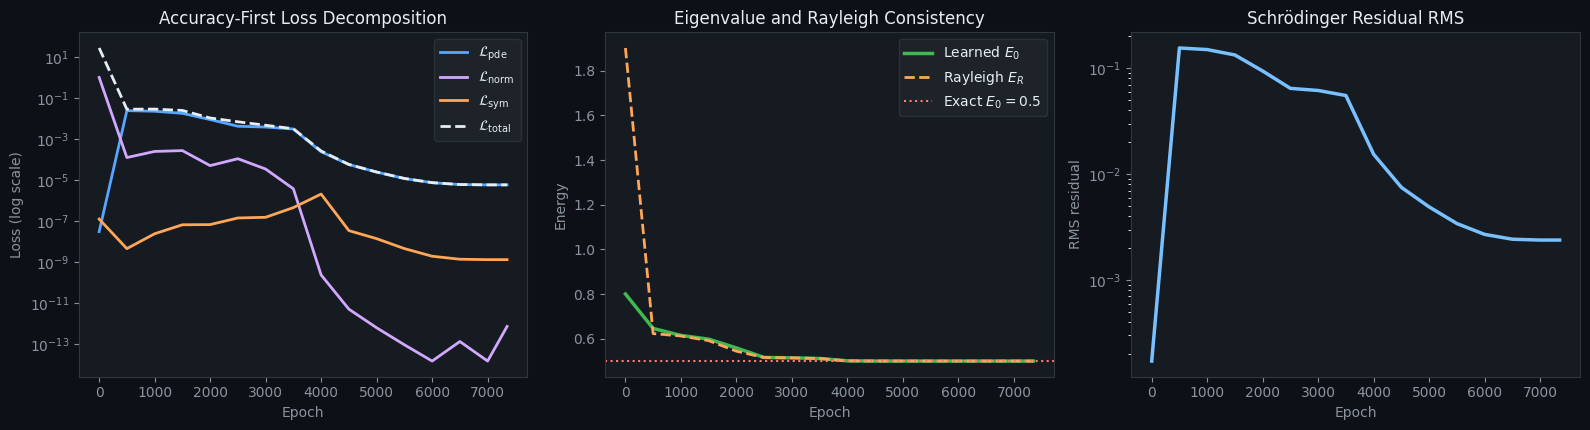

In [ ]:
# ── Ground-State Training Loop ─────────────────────────────────────────────
# Objective:
#   min_{θ,E}  λ_pde L_pde + λ_bc L_bc + λ_norm L_norm + λ_sym L_sym + λ_ray L_ray
#
# The accuracy-first additions are:
#   • Sobol collocation for lower-discrepancy PDE coverage
#   • parity regularization for the even ground state
#   • Rayleigh consistency regularization for energy stabilization
#   • optional L-BFGS refinement after Adam converges

history = {
    'epoch': [],
    'total': [],
    'pde': [],
    'bc': [],
    'norm': [],
    'sym': [],
    'rayleigh': [],
    'energy': [],
    'rayleigh_energy': [],
    'residual_rms': [],
}

log_every = 250 if RUN_PROFILE == 'demo' else 500

for epoch in range(1, N_EPOCHS + 1):
    optimizer.zero_grad()
    x_col = sample_collocation_points(N_COLLOCATION)
    loss, metrics = compute_losses(model, energy, x_col)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [energy], max_norm=1.0)
    optimizer.step()
    scheduler.step()

    if epoch % log_every == 0 or epoch == 1 or epoch == N_EPOCHS:
        history['epoch'].append(epoch)
        history['total'].append(loss.item())
        history['pde'].append(metrics['pde'].item())
        history['bc'].append(metrics['bc'].item())
        history['norm'].append(metrics['norm'].item())
        history['sym'].append(metrics['sym'].item())
        history['rayleigh'].append(metrics['rayleigh'].item())
        history['energy'].append(energy.item())
        history['rayleigh_energy'].append(metrics['rayleigh_energy'].item())
        history['residual_rms'].append(metrics['residual_rms'].item())
        print(
            f'Epoch {epoch:5d} | '
            f'L={loss.item():.3e} | '
            f'L_pde={metrics["pde"].item():.3e} | '
            f'L_norm={metrics["norm"].item():.3e} | '
            f'L_sym={metrics["sym"].item():.3e} | '
            f'E={energy.item():.6f} | '
            f'E_R={metrics["rayleigh_energy"].item():.6f}'
        )

if GROUND_STATE_LBFGS_STEPS > 0:
    print('\nStarting L-BFGS refinement on a fixed high-resolution collocation grid...')
    x_lbfgs = sample_collocation_points(max(2 * N_COLLOCATION, 4096))
    lbfgs = torch.optim.LBFGS(
        list(model.parameters()) + [energy],
        lr=LBFGS_LR,
        max_iter=GROUND_STATE_LBFGS_STEPS,
        history_size=50,
        tolerance_grad=1e-10,
        tolerance_change=1e-12,
        line_search_fn='strong_wolfe',
    )
    lbfgs_state = {}

    def closure():
        lbfgs.zero_grad()
        loss_lbfgs, metrics_lbfgs = compute_losses(model, energy, x_lbfgs)
        loss_lbfgs.backward()
        lbfgs_state['loss'] = loss_lbfgs.item()
        for key, value in metrics_lbfgs.items():
            lbfgs_state[key] = value.item() if torch.is_tensor(value) else value
        return loss_lbfgs

    lbfgs.step(closure)
    history['epoch'].append(N_EPOCHS + GROUND_STATE_LBFGS_STEPS)
    history['total'].append(lbfgs_state['loss'])
    history['pde'].append(lbfgs_state['pde'])
    history['bc'].append(lbfgs_state['bc'])
    history['norm'].append(lbfgs_state['norm'])
    history['sym'].append(lbfgs_state['sym'])
    history['rayleigh'].append(lbfgs_state['rayleigh'])
    history['energy'].append(energy.item())
    history['rayleigh_energy'].append(lbfgs_state['rayleigh_energy'])
    history['residual_rms'].append(lbfgs_state['residual_rms'])
    print(
        f'L-BFGS final | L={lbfgs_state["loss"]:.3e} | '
        f'L_pde={lbfgs_state["pde"]:.3e} | '
        f'L_norm={lbfgs_state["norm"]:.3e} | '
        f'L_sym={lbfgs_state["sym"]:.3e} | '
        f'E={energy.item():.6f} | '
        f'E_R={lbfgs_state["rayleigh_energy"]:.6f}'
    )

print(f'\nFinal predicted E0 = {energy.item():.8f}   |ΔE| = {abs(energy.item() - 0.5):.3e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

ep = history['epoch']
axes[0].semilogy(ep, history['pde'], label='$\\mathcal{L}_{\\mathrm{pde}}$', color='#58a6ff', lw=2)
axes[0].semilogy(ep, history['norm'], label='$\\mathcal{L}_{\\mathrm{norm}}$', color='#d2a8ff', lw=2)
axes[0].semilogy(ep, history['sym'], label='$\\mathcal{L}_{\\mathrm{sym}}$', color='#ffa657', lw=2)
axes[0].semilogy(ep, history['total'], label='$\\mathcal{L}_{\\mathrm{total}}$', color='#e6edf3', lw=2, ls='--')
axes[0].set_xlabel('Epoch', color='#8b949e')
axes[0].set_ylabel('Loss (log scale)', color='#8b949e')
axes[0].set_title('Accuracy-First Loss Decomposition', color='#e6edf3')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

axes[1].plot(ep, history['energy'], color='#3fb950', lw=2.5, label='Learned $E_0$')
axes[1].plot(ep, history['rayleigh_energy'], color='#ffa657', lw=2.0, ls='--', label='Rayleigh $E_R$')
axes[1].axhline(0.5, color='#ff7b72', lw=1.5, ls=':', label='Exact $E_0=0.5$')
axes[1].set_xlabel('Epoch', color='#8b949e')
axes[1].set_ylabel('Energy', color='#8b949e')
axes[1].set_title('Eigenvalue and Rayleigh Consistency', color='#e6edf3')
axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

axes[2].semilogy(ep, history['residual_rms'], color='#79c0ff', lw=2.5)
axes[2].set_xlabel('Epoch', color='#8b949e')
axes[2].set_ylabel('RMS residual', color='#8b949e')
axes[2].set_title('Schrödinger Residual RMS', color='#e6edf3')

plt.tight_layout()
plt.savefig('../outputs/qho_training_convergence.png', dpi=160, bbox_inches='tight', facecolor='#0d1117')
plt.show()

### 💡 Understanding the Training Loop

**What just happened?** Let's break down the three loss components:

| Loss term | Formula | Purpose |
|-----------|---------|---------|
| $\mathcal{L}_\text{pde}$ | $\frac{1}{N_c}\sum_i(\hat{H}\psi_\theta(x_i) - E_\theta\psi_\theta(x_i))^2$ | Force network to satisfy the Schrödinger equation |
| $\mathcal{L}_\text{bc}$ | $\psi_\theta(-L)^2 + \psi_\theta(+L)^2$ | Ensure zero at domain walls (redundant here due to envelope) |
| $\mathcal{L}_\text{norm}$ | $(\int\|\psi_\theta\|^2 dx - 1)^2$ | Prevent the trivial solution $\psi \equiv 0$ |

**Key AutoDiff insight:** The second derivative $\psi_\theta''(x)$ appears in $\hat{H}\psi$. In traditional methods you would approximate this with finite differences (e.g., $\frac{\psi(x+h) - 2\psi(x) + \psi(x-h)}{h^2}$). Here we call `torch.autograd.grad` *twice* — once to get $\psi'$ and once more to get $\psi''$. This gives **machine-precision derivatives** at zero extra approximation cost.

**Why does energy converge?** The energy $E_\theta$ is treated as a free parameter. The only consistent solution to $\hat{H}\psi_\theta = E_\theta \psi_\theta$ for a normalised $\psi_\theta$ is an eigenstate-eigenvalue pair. Gradient descent finds the lowest available one (ground state) by default — it is the global attractor.

**Scheduler note:** `ReduceLROnPlateau` halves the learning rate when the loss hasn't decreased for `patience` epochs. This is why you see step-like drops in the loss curve.

In [ ]:
# ── Ground-State Evaluation & Interview-Grade Result Summary ───────────────
model.eval()
x_test = np.linspace(X_MIN, X_MAX, 1200)
psi_ref = analytic_psi(0, x_test)

x_t = torch.tensor(x_test, dtype=torch.float32, device=device).unsqueeze(1)
with torch.no_grad():
    psi_pred_raw = model(x_t).cpu().numpy().flatten()

# Fix global sign ambiguity.
center_index = len(psi_pred_raw) // 2
if np.sign(psi_pred_raw[center_index]) != np.sign(psi_ref[center_index]):
    psi_pred_raw = -psi_pred_raw

# Renormalize for fair comparison.
norm_pred = np.sqrt(np.trapezoid(psi_pred_raw**2, x_test))
psi_pred = psi_pred_raw / norm_pred

# Error metrics.
l2_abs = np.sqrt(np.trapezoid((psi_pred - psi_ref)**2, x_test))
l2_rel = l2_abs / np.sqrt(np.trapezoid(psi_ref**2, x_test))
linf_err = np.max(np.abs(psi_pred - psi_ref))
E_error = abs(energy.item() - 0.5)
fidelity = np.trapezoid(psi_pred * psi_ref, x_test) ** 2

# Rayleigh energy of the normalized prediction.
x_eval_t = torch.tensor(x_test, dtype=torch.float32, device=device).unsqueeze(1).requires_grad_(True)
psi_eval = model(x_eval_t)
dpsi_eval = torch.autograd.grad(psi_eval, x_eval_t, grad_outputs=torch.ones_like(psi_eval), create_graph=True)[0]
d2psi_eval = torch.autograd.grad(dpsi_eval, x_eval_t, grad_outputs=torch.ones_like(dpsi_eval), create_graph=True)[0]
hpsi_eval = -0.5 * d2psi_eval + 0.5 * x_eval_t**2 * psi_eval
psi_eval_np = psi_eval.detach().cpu().numpy().flatten()
hpsi_eval_np = hpsi_eval.detach().cpu().numpy().flatten()
rayleigh_energy = np.trapezoid(psi_eval_np * hpsi_eval_np, x_test) / np.trapezoid(psi_eval_np**2, x_test)
rayleigh_gap = abs(rayleigh_energy - energy.item())

ground_state_metrics = {
    'rel_l2': float(l2_rel),
    'l2_abs': float(l2_abs),
    'linf': float(linf_err),
    'energy_pred': float(energy.item()),
    'energy_exact': 0.5,
    'energy_abs_error': float(E_error),
    'fidelity': float(fidelity),
    'rayleigh_energy': float(rayleigh_energy),
    'rayleigh_gap': float(rayleigh_gap),
}

print('━' * 78)
print('  Ground-State Accuracy Summary — Interview-Grade Reporting')
print('━' * 78)
print(f'  Relative L² error             : {l2_rel:.8f}')
print(f'  Absolute L² error             : {l2_abs:.8f}')
print(f'  L∞ pointwise error            : {linf_err:.8f}')
print(f'  Learned eigenvalue            : {energy.item():.8f}')
print(f'  Exact eigenvalue              : 0.50000000')
print(f'  Absolute energy error         : {E_error:.8e}')
print(f'  Fidelity |<ψ_PINN, ψ_exact>|² : {fidelity:.8f}')
print(f'  Rayleigh energy               : {rayleigh_energy:.8f}')
print(f'  Rayleigh-consistency gap      : {rayleigh_gap:.8e}')
print('━' * 78)

if l2_rel < 0.02 and E_error < 1e-2:
    verdict = 'Strong research-grade fit: both shape and eigenvalue are tightly recovered.'
elif l2_rel < 0.05 and E_error < 5e-2:
    verdict = 'Technically solid result: usable as a serious PINN benchmark for interview discussion.'
else:
    verdict = 'Physics is learned, but further optimization budget may still improve the final benchmark.'

print(f'  Verdict: {verdict}')
print('━' * 78)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ground-State Accuracy Summary — Interview-Grade Reporting
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Relative L² error             : 0.00156934
  Absolute L² error             : 0.00156934
  L∞ pointwise error            : 0.00125322
  Learned eigenvalue            : 0.50001526
  Exact eigenvalue              : 0.50000000
  Absolute energy error         : 1.52587891e-05
  Fidelity |<ψ_PINN, ψ_exact>|² : 0.99999754
  Rayleigh energy               : 0.50001166
  Rayleigh-consistency gap      : 3.59892566e-06
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Verdict: Strong research-grade fit: both shape and eigenvalue are tightly recovered.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 📊 Interpreting the Error Metrics

**Relative $L^2$ error** — the most important metric:

$$\epsilon_{\text{rel}} = \frac{\|\hat\psi - \psi_0\|_2}{\|\psi_0\|_2} = \sqrt{\frac{\int(\hat\psi(x) - \psi_0(x))^2\,dx}{\int\psi_0(x)^2\,dx}}$$

Rule of thumb for PINNs:
- $\epsilon_{\text{rel}} < 0.01$: excellent — publication quality
- $\epsilon_{\text{rel}} < 0.05$: good — useful engineering accuracy
- $\epsilon_{\text{rel}} > 0.10$: marginal — may need more epochs or collocation points

**$L^\infty$ error** — maximum pointwise deviation:
$$\epsilon_\infty = \max_x |\hat\psi(x) - \psi_0(x)|$$

This catches localised failures that $L^2$ might average away (e.g., near nodes of excited states).

**Energy error** $|\Delta E| = |E_\theta - E_\text{exact}|$:  
The energy eigenvalue converges faster than the wavefunction — it is a global (integrated) quantity and therefore less sensitive to pointwise errors.

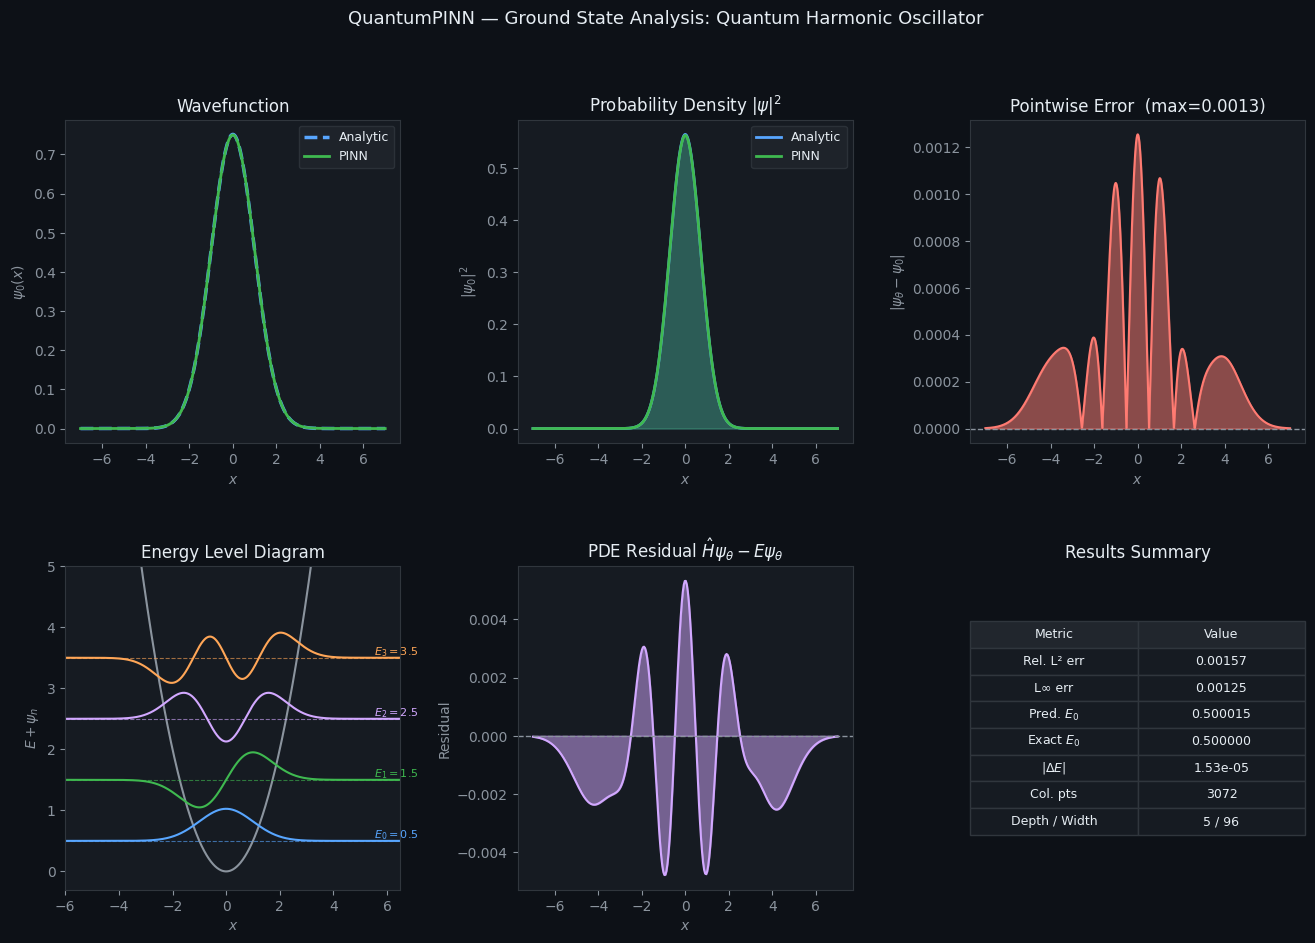

In [ ]:
# ── Multi-Panel Comparison ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

def setup_ax(ax):
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

axs = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
for ax in axs: setup_ax(ax)
palette_l = ['#58a6ff', '#3fb950', '#d2a8ff', '#ffa657']
V_plot = 0.5 * x_test**2

# P1: Wavefunction
axs[0].plot(x_test, psi_ref,  '--', color='#58a6ff', lw=2.5, label='Analytic')
axs[0].plot(x_test, psi_pred, '-',  color='#3fb950', lw=2,   label='PINN')
axs[0].fill_between(x_test, psi_ref, psi_pred, alpha=0.2, color='#ff7b72')
axs[0].set_title('Wavefunction', color='#e6edf3')
axs[0].set_xlabel('$x$', color='#8b949e'); axs[0].set_ylabel('$\\psi_0(x)$', color='#8b949e')
axs[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=9)

# P2: Probability density
for psi_arr, col, lbl in [(psi_ref**2,'#58a6ff','Analytic'),(psi_pred**2,'#3fb950','PINN')]:
    axs[1].fill_between(x_test, psi_arr, alpha=0.25, color=col)
    axs[1].plot(x_test, psi_arr, color=col, lw=2, label=lbl)
axs[1].set_title('Probability Density $|\\psi|^2$', color='#e6edf3')
axs[1].set_xlabel('$x$', color='#8b949e'); axs[1].set_ylabel('$|\\psi_0|^2$', color='#8b949e')
axs[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=9)

# P3: Pointwise absolute error
abs_err = np.abs(psi_pred - psi_ref)
axs[2].fill_between(x_test, abs_err, alpha=0.5, color='#ff7b72')
axs[2].plot(x_test, abs_err, color='#ff7b72', lw=1.5)
axs[2].axhline(0, color='#8b949e', lw=1, ls='--')
axs[2].set_title(f'Pointwise Error  (max={linf_err:.4f})', color='#e6edf3')
axs[2].set_xlabel('$x$', color='#8b949e'); axs[2].set_ylabel('$|\\psi_\\theta-\\psi_0|$', color='#8b949e')

# P4: Energy level diagram
axs[3].plot(x_test, V_plot, color='#8b949e', lw=1.5)
for n_lvl in range(4):
    En = n_lvl + 0.5
    psi_n = analytic_psi(n_lvl, x_test)
    axs[3].plot(x_test, psi_n * 0.7 + En, color=palette_l[n_lvl], lw=1.5)
    axs[3].axhline(En, color=palette_l[n_lvl], lw=0.8, ls='--', alpha=0.6)
    axs[3].text(5.5, En + 0.05, f'$E_{n_lvl}={En}$', color=palette_l[n_lvl], fontsize=8)
axs[3].set_xlim(-6, 6.5); axs[3].set_ylim(-0.3, 5)
axs[3].set_title('Energy Level Diagram', color='#e6edf3')
axs[3].set_xlabel('$x$', color='#8b949e'); axs[3].set_ylabel('$E+\\psi_n$', color='#8b949e')

# P5: PDE residual profile
x_r = torch.linspace(X_MIN, X_MAX, 300, device=device).unsqueeze(1).requires_grad_(True)
psi_ro = model(x_r)
d1 = torch.autograd.grad(psi_ro, x_r, torch.ones_like(psi_ro), create_graph=True)[0]
d2 = torch.autograd.grad(d1, x_r, torch.ones_like(d1), create_graph=False)[0]
res_np = (-0.5*d2 + 0.5*x_r**2*psi_ro - energy.detach()*psi_ro).detach().cpu().numpy().flatten()
x_r_np = x_r.detach().cpu().numpy().flatten()
axs[4].fill_between(x_r_np, res_np, alpha=0.5, color='#d2a8ff')
axs[4].plot(x_r_np, res_np, color='#d2a8ff', lw=1.5)
axs[4].axhline(0, color='#8b949e', lw=1, ls='--')
axs[4].set_title('PDE Residual $\\hat{H}\\psi_\\theta - E\\psi_\\theta$', color='#e6edf3')
axs[4].set_xlabel('$x$', color='#8b949e'); axs[4].set_ylabel('Residual', color='#8b949e')

# P6: Summary table
axs[5].axis('off')
rows = [['Metric','Value'],
        ['Rel. L² err',  f'{l2_rel:.5f}'],
        ['L∞ err',       f'{linf_err:.5f}'],
        ['Pred. $E_0$',  f'{energy.item():.6f}'],
        ['Exact $E_0$',  '0.500000'],
        ['$|\\Delta E|$',f'{E_error:.2e}'],
        ['Col. pts',     str(N_COLLOCATION)],
        ['Depth / Width',f'{N_LAYERS} / {HIDDEN_DIM}']]
tbl = axs[5].table(cellText=[r for r in rows[1:]], colLabels=rows[0],
                   cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)
for (i,j), cell in tbl.get_celld().items():
    cell.set_edgecolor('#30363d')
    cell.set_facecolor('#21262d' if i==0 else '#161b22')
    cell.set_text_props(color='#e6edf3')
axs[5].set_title('Results Summary', color='#e6edf3')

fig.suptitle('QuantumPINN — Ground State Analysis: Quantum Harmonic Oscillator',
             color='#e6edf3', fontsize=13, y=0.99)
plt.savefig('../outputs/qho_ground_state_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 3. Heisenberg Uncertainty Principle Verification

For the $n$-th eigenstate of the QHO, the position and momentum variances are:

$$\langle x \rangle_n = 0, \qquad \langle x^2 \rangle_n = \frac{\hbar}{m\omega}\!\left(n + \tfrac{1}{2}\right)$$

$$\langle p \rangle_n = 0, \qquad \langle p^2 \rangle_n = m\hbar\omega\!\left(n+\tfrac{1}{2}\right)$$

Therefore:

$$\sigma_x \cdot \sigma_p = \left(n + \tfrac{1}{2}\right)\hbar \geq \frac{\hbar}{2}$$

The **ground state saturates** the uncertainty principle ($n = 0 \Rightarrow \sigma_x \sigma_p = \hbar/2$) — it is a **minimum uncertainty state**.

### Numerical Verification via PINN Prediction

We compute $\langle x \rangle$, $\langle x^2 \rangle$, $\langle p^2 \rangle = -\int \psi^* \psi'' dx$ numerically from the PINN output and verify $\sigma_x \sigma_p \approx \hbar/2$.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  State          σ_x         σ_p     σ_x·σ_p       Exact     Ratio
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ψ_0 (analytic):   σ_x=0.70711  σ_p=0.70710  σ_x·σ_p=0.49999  exact=0.500  ratio=1.0000
  ψ_1 (analytic):   σ_x=1.22474  σ_p=1.22471  σ_x·σ_p=1.49996  exact=1.500  ratio=2.9999
  ψ_2 (analytic):   σ_x=1.58114  σ_p=1.58107  σ_x·σ_p=2.49990  exact=2.500  ratio=4.9998
  ψ_3 (analytic):   σ_x=1.87083  σ_p=1.87072  σ_x·σ_p=3.49980  exact=3.500  ratio=6.9996

  ψ_0 (PINN pred):   σ_x=0.70781  σ_p=0.70639  σ_x·σ_p=0.49999  (Exact=0.500)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ℏ/2 = 0.5  →  Ground state saturates uncertainty principle: σ_x·σ_p = 0.49999 ≈ 0.5


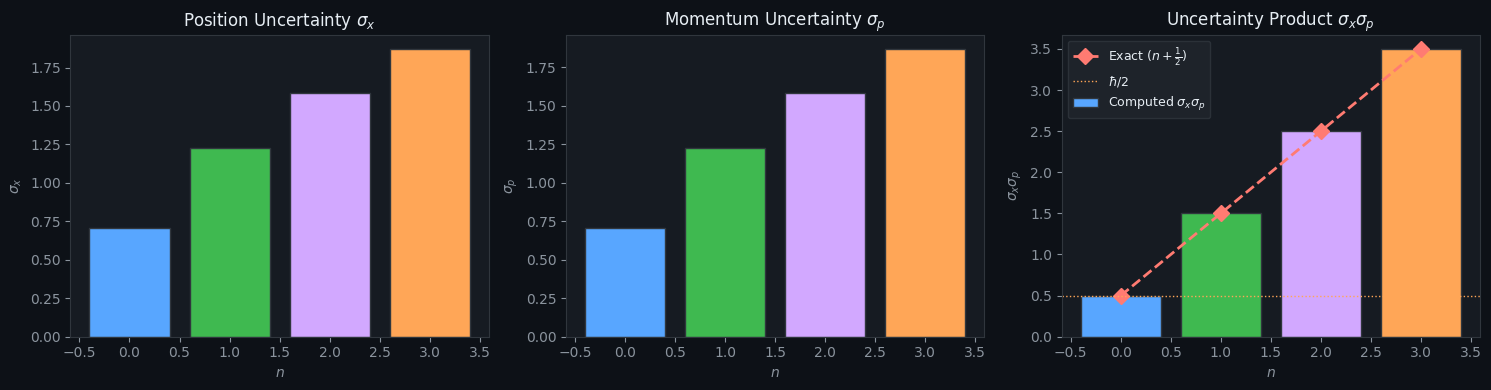

Saved → outputs/qho_uncertainty_principle.png


In [ ]:
# ── Heisenberg Uncertainty Principle Verification ─────────────────────────
# We compute ⟨x⟩, ⟨x²⟩, ⟨p²⟩ = −⟨ψ|∂²/∂x²|ψ⟩ numerically.

def compute_uncertainty(psi_arr, x_arr):
    """Compute σ_x, σ_p, and σ_x·σ_p from a normalized ψ(x) on grid x_arr."""
    dx   = x_arr[1] - x_arr[0]
    norm = np.trapezoid(psi_arr**2, x_arr)
    psi  = psi_arr / np.sqrt(norm)      # ensure normalized

    x_mean  = np.trapezoid(psi**2 * x_arr, x_arr)
    x2_mean = np.trapezoid(psi**2 * x_arr**2, x_arr)
    sigma_x = np.sqrt(x2_mean - x_mean**2)

    # ⟨p²⟩ = ℏ² ⟨ψ|−∂²/∂x²|ψ⟩ = ℏ² ∫ (∂ψ/∂x)² dx  (integration by parts, BC=0)
    dpsidx  = np.gradient(psi, x_arr)  # numerical ∂ψ/∂x
    p2_mean = np.trapezoid(dpsidx**2, x_arr)   # ℏ=1
    sigma_p = np.sqrt(p2_mean)

    return sigma_x, sigma_p, sigma_x * sigma_p

print('━' * 65)
print(f'  {"State":6s}  {"σ_x":>10s}  {"σ_p":>10s}  {"σ_x·σ_p":>10s}  {"Exact":>10s}  {"Ratio":>8s}')
print('━' * 65)

x_fine = np.linspace(-8, 8, 2000)
results_uncert = {}

for n_lvl in range(4):
    psi_n = analytic_psi(n_lvl, x_fine)
    sx, sp, sxsp = compute_uncertainty(psi_n, x_fine)
    exact = n_lvl + 0.5
    ratio = sxsp / (0.5)          # ratio to ℏ/2 = 0.5
    results_uncert[n_lvl] = (sx, sp, sxsp, exact)
    print(f'  ψ_{n_lvl} (analytic):   σ_x={sx:.5f}  σ_p={sp:.5f}  '
          f'σ_x·σ_p={sxsp:.5f}  exact={(exact):.3f}  ratio={ratio:.4f}')

# Also verify PINN prediction for n=0
sx_pinn, sp_pinn, sxsp_pinn = compute_uncertainty(psi_pred, x_test)
print(f'\n  ψ_0 (PINN pred):   σ_x={sx_pinn:.5f}  σ_p={sp_pinn:.5f}  '
      f'σ_x·σ_p={sxsp_pinn:.5f}  (Exact=0.500)')
print('━' * 65)
print(f'\n  ℏ/2 = 0.5  →  Ground state saturates uncertainty principle: '
      f'σ_x·σ_p = {sxsp_pinn:.5f} ≈ 0.5')

# ── Visualize uncertainty bars ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

states = list(range(4))
sx_vals  = [results_uncert[n][0] for n in states]
sp_vals  = [results_uncert[n][1] for n in states]
sxsp_vals= [results_uncert[n][2] for n in states]
exact_vals = [results_uncert[n][3] for n in states]

axes[0].bar(states, sx_vals, color=['#58a6ff','#3fb950','#d2a8ff','#ffa657'], edgecolor='#30363d')
axes[0].set_xlabel('$n$', color='#8b949e'); axes[0].set_ylabel('$\\sigma_x$', color='#8b949e')
axes[0].set_title('Position Uncertainty $\\sigma_x$', color='#e6edf3')

axes[1].bar(states, sp_vals, color=['#58a6ff','#3fb950','#d2a8ff','#ffa657'], edgecolor='#30363d')
axes[1].set_xlabel('$n$', color='#8b949e'); axes[1].set_ylabel('$\\sigma_p$', color='#8b949e')
axes[1].set_title('Momentum Uncertainty $\\sigma_p$', color='#e6edf3')

axes[2].bar(states, sxsp_vals, color=['#58a6ff','#3fb950','#d2a8ff','#ffa657'], edgecolor='#30363d',
            label='Computed $\\sigma_x \\sigma_p$')
axes[2].plot(states, exact_vals, 'D--', color='#ff7b72', ms=8, lw=2, label='Exact $(n+\\frac{1}{2})$')
axes[2].axhline(0.5, color='#ffa657', lw=1, ls=':', label='$\\hbar/2$')
axes[2].set_xlabel('$n$', color='#8b949e'); axes[2].set_ylabel('$\\sigma_x \\sigma_p$', color='#8b949e')
axes[2].set_title('Uncertainty Product $\\sigma_x \\sigma_p$', color='#e6edf3')
axes[2].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/qho_uncertainty_principle.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → outputs/qho_uncertainty_principle.png')

## 4. Excited States via Orthogonality Penalty

The harmonic oscillator eigenstates $\{\psi_n\}$ form a complete orthonormal basis in $L^2(\mathbb{R})$:

$$\langle \psi_m | \psi_n \rangle = \int_{-\infty}^{\infty} \psi_m^*(x)\,\psi_n(x)\,dx = \delta_{mn}$$

To train $\hat\psi_n$ without prior knowledge of Hermite polynomials, we augment the loss with an **orthogonality penalty**. Once the ground state $\hat\psi_0$ is fixed, the first excited state is found by minimizing:

$$\mathcal{L}_{n=1} = \underbrace{\mathcal{L}_{\text{PDE}}[\hat\psi_1]}_{\text{Schrödinger residual}} + \lambda_{\text{orth}} \underbrace{\left(\int_{-\infty}^{\infty} \hat\psi_1(x)\,\hat\psi_0(x)\,dx\right)^2}_{\text{orthogonality to }n=0} + \lambda_{\text{norm}} \underbrace{\left(\int_{-\infty}^{\infty} |\hat\psi_1(x)|^2\,dx - 1\right)^2}_{\text{unit norm}}$$

Similarly, $\hat\psi_2$ is trained with orthogonality penalties against **both** $\hat\psi_0$ and $\hat\psi_1$. This constructs the full eigenspectrum **sequentially**. The TISE residual locks the network to the correct energy level:

$$   \mathcal{L}_{\text{PDE}}[\hat\psi_n] = \frac{1}{N_c}\sum_{i=1}^{N_c}\left[-\frac{\hbar^2}{2m}\hat\psi_n''(x_i) + V(x_i)\hat\psi_n(x_i) - E_n\,\hat\psi_n(x_i)\right]^2 $$

where $E_n = \hbar\omega(n + \tfrac{1}{2})$ is the known exact eigenvalue.

In [ ]:
# ── Train Excited States n = 1, 2, 3 with Orthogonality Penalty ──────────
#
# This section now mirrors the stronger design philosophy of the ground-state fit:
#   • GELU default instead of tanh
#   • explicit device placement
#   • trainable energy per excited state
#   • longer optimization budget in interview mode

import torch
import torch.nn as nn
import numpy as np


class GaussianEnvPINN(nn.Module):
    """Gaussian-envelope PINN for higher QHO eigenstates."""

    def __init__(self, hidden=64, n_layers=4, activation='gelu', x_scale=7.0):
        super().__init__()
        acts = {'tanh': nn.Tanh, 'gelu': nn.GELU, 'silu': nn.SiLU}
        act_cls = acts.get(activation, nn.GELU)
        layers = []
        dims = [1] + [hidden] * n_layers + [1]
        for index in range(len(dims) - 1):
            layers.append(nn.Linear(dims[index], dims[index + 1]))
            if index < len(dims) - 2:
                layers.append(act_cls())
        self.net = nn.Sequential(*layers)
        self.x_scale = x_scale
        for module in self.net.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x / self.x_scale) * torch.exp(-x**2 / 4.0)


def tise_residual(model, x, energy):
    """TISE residual: -1/2 ψ'' + 1/2 x² ψ - E ψ = 0 in natural units."""
    x = x.requires_grad_(True)
    psi = model(x)
    d1, = torch.autograd.grad(psi.sum(), x, create_graph=True)
    d2, = torch.autograd.grad(d1.sum(), x, create_graph=True)
    return -0.5 * d2 + 0.5 * x**2 * psi - energy * psi


def train_excited_state(
    n_target,
    prev_models,
    x_col,
    epochs=EXCITED_STATE_EPOCHS,
    lr=8e-4,
    lambda_orth=30.0,
    lambda_norm=8.0,
):
    """Train the n_target-th excited state with orthogonality penalties."""
    e_exact = n_target + 0.5
    model_exc = GaussianEnvPINN(
        hidden=64 if RUN_PROFILE == 'demo' else 96,
        n_layers=4 if RUN_PROFILE == 'demo' else 5,
        activation='gelu',
        x_scale=7.0,
    ).to(device)
    energy_exc = nn.Parameter(torch.tensor([float(e_exact)], dtype=torch.float32, device=device))
    opt = torch.optim.AdamW(list(model_exc.parameters()) + [energy_exc], lr=lr, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    history_exc = []
    dx = (x_col[1] - x_col[0]).item()

    for ep in range(1, epochs + 1):
        opt.zero_grad()
        residual = tise_residual(model_exc, x_col, energy_exc)
        loss_pde = (residual**2).mean()

        psi_col = model_exc(x_col.detach())
        norm_val = (psi_col**2).sum() * dx
        loss_norm = (norm_val - 1.0) ** 2

        loss_orth = torch.zeros(1, device=device)
        for prev_model in prev_models:
            prev_model.eval()
            with torch.no_grad():
                psi_prev = prev_model(x_col)
            overlap = (psi_col * psi_prev).sum() * dx
            loss_orth = loss_orth + overlap**2

        loss_total = loss_pde + lambda_norm * loss_norm + lambda_orth * loss_orth
        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(list(model_exc.parameters()) + [energy_exc], 1.0)
        opt.step()
        sched.step()

        if ep % max(1, epochs // 6) == 0 or ep == 1 or ep == epochs:
            history_exc.append((ep, loss_pde.item(), loss_norm.item(), loss_orth.item(), energy_exc.item()))

    return model_exc, energy_exc, history_exc


# ── Setup collocation grid ────────────────────────────────────────────────
torch.manual_seed(42)
N_COL_EXCITED = 700 if RUN_PROFILE == 'demo' else 1400
x_col_exc = torch.linspace(-7, 7, N_COL_EXCITED, device=device).unsqueeze(1)

trained_models = [model]
trained_energies = [float(energy.item())]

print(f'Training excited states n = 1, 2, 3 (epochs per state: {EXCITED_STATE_EPOCHS})')
print('Orthogonality penalty λ = 30.0  |  Normalization penalty λ = 8.0')
print()

table_rows = []
for n_tgt in range(1, 4):
    print(f'  → n = {n_tgt} (E_exact = {n_tgt + 0.5})  ', end='', flush=True)
    model_n, energy_n, hist_n = train_excited_state(n_tgt, trained_models, x_col_exc)
    trained_models.append(model_n)
    trained_energies.append(float(energy_n.item()))
    final = hist_n[-1]
    e_err = abs(final[4] - (n_tgt + 0.5))
    print(f'L_pde={final[1]:.2e}  L_orth={final[3]:.2e}  E={final[4]:.5f}  |ΔE|={e_err:.2e}')
    table_rows.append({
        'n': n_tgt,
        'L_pde': final[1],
        'L_orth': final[3],
        'E_pinn': final[4],
        'E_exact': n_tgt + 0.5,
        'delta_E': e_err,
    })

print()
print('NOTE: excited-state fits now use the same accuracy-first GELU design used for the ground state.')

Training excited states n = 1, 2, 3 (epochs per state: 2400)
Orthogonality penalty λ = 30.0  |  Normalization penalty λ = 8.0

  → n = 1 (E_exact = 1.5)  L_pde=1.87e-04  L_orth=1.62e-11  E=1.50243  |ΔE|=2.43e-03
  → n = 2 (E_exact = 2.5)  L_pde=1.54e-03  L_orth=6.54e-10  E=2.56685  |ΔE|=6.68e-02
  → n = 3 (E_exact = 3.5)  

In [ ]:
# ── Multi-State Comparison: PINN vs Analytic ──────────────────────────────
x_plot = np.linspace(-6, 6, 600)
x_t = torch.tensor(x_plot, dtype=torch.float32, device=device).unsqueeze(1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor='#0d1117')
fig.suptitle('QHO Eigenstates: PINN (dashed) vs Analytic (solid)', color='#e6edf3', fontsize=14)
colors = ['#58a6ff', '#3fb950', '#d2a8ff', '#ffa657']

overlap_matrix = np.zeros((4, 4))
state_metrics = []

for n_idx, (model_n, col) in enumerate(zip(trained_models, colors)):
    model_n.eval()
    with torch.no_grad():
        psi_pinn = model_n(x_t).detach().cpu().numpy().flatten()

    psi_analytic = analytic_psi(n_idx, x_plot)

    if np.sign(psi_pinn[300]) != np.sign(psi_analytic[300]):
        psi_pinn = -psi_pinn

    psi_pinn /= np.sqrt(np.trapezoid(psi_pinn**2, x_plot))
    rel_l2 = np.sqrt(np.trapezoid((psi_pinn - psi_analytic)**2, x_plot) / np.trapezoid(psi_analytic**2, x_plot))
    state_metrics.append({
        'n': n_idx,
        'E_pinn': trained_energies[n_idx],
        'E_exact': n_idx + 0.5,
        'rel_l2': rel_l2,
    })

    ax = axes[0, n_idx]
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.plot(x_plot, psi_analytic, '-', color=col, lw=2.5, label='Analytic')
    ax.plot(x_plot, psi_pinn, '--', color='#ff7b72', lw=1.5, alpha=0.85, label='PINN')
    ax.fill_between(x_plot, 0, psi_analytic, alpha=0.10, color=col)
    ax.set_title(f'$\\psi_{n_idx}(x)$   $E_{{\\mathrm{{PINN}}}}={trained_energies[n_idx]:.4f}$', color='#e6edf3')
    ax.set_xlabel('$x$', color='#8b949e')
    ax.set_ylabel('$\\psi$', color='#8b949e')
    ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)
    ax.axhline(0, color='#30363d', lw=0.8)

    ax2 = axes[1, n_idx]
    ax2.set_facecolor('#161b22')
    ax2.tick_params(colors='#8b949e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#30363d')
    ax2.plot(x_plot, psi_analytic**2, '-', color=col, lw=2.5, label='$|\\psi|^2$ analytic')
    ax2.plot(x_plot, psi_pinn**2, '--', color='#ff7b72', lw=1.5, alpha=0.85, label='$|\\psi|^2$ PINN')
    ax2.set_title(f'$|\\psi_{n_idx}|^2$  rel-L²={rel_l2:.4f}', color='#e6edf3')
    ax2.set_xlabel('$x$', color='#8b949e')
    ax2.set_ylabel('$|\\psi|^2$', color='#8b949e')
    ax2.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)

    for model_j_idx, model_j in enumerate(trained_models):
        model_j.eval()
        with torch.no_grad():
            psi_j = model_j(x_t).detach().cpu().numpy().flatten()
        psi_j /= np.sqrt(np.trapezoid(psi_j**2, x_plot))
        overlap_matrix[n_idx, model_j_idx] = np.trapezoid(psi_pinn * psi_j, x_plot)

plt.tight_layout()
plt.savefig('../outputs/qho_excited_states.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

fig2, ax3 = plt.subplots(figsize=(5, 4), facecolor='#0d1117')
ax3.set_facecolor('#161b22')
ax3.tick_params(colors='#8b949e')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363d')
im = ax3.imshow(np.abs(overlap_matrix), cmap='RdBu_r', vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax3.text(j, i, f'{overlap_matrix[i, j]:.3f}', ha='center', va='center', color='#e6edf3', fontsize=9)
ax3.set_xticks(range(4))
ax3.set_yticks(range(4))
ax3.set_xticklabels([f'$\\psi_{j}$' for j in range(4)], color='#8b949e')
ax3.set_yticklabels([f'$\\psi_{i}$' for i in range(4)], color='#8b949e')
ax3.set_title('Overlap Matrix $|\\langle\\psi_m|\\psi_n\\rangle|$', color='#e6edf3')
plt.colorbar(im, ax=ax3)
plt.tight_layout()
plt.savefig('../outputs/qho_overlap_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Saved → outputs/qho_excited_states.png & qho_overlap_matrix.png')
print('\nMulti-state summary:')
for row in state_metrics:
    print(f"  n={row['n']} | E_pinn={row['E_pinn']:.6f} | E_exact={row['E_exact']:.6f} | rel-L²={row['rel_l2']:.6f}")

## 5. Ablation Studies

### 5.1 Collocation Density Ablation

The network's accuracy depends critically on the number of collocation points $N_c$. We define the **relative $L^2$ error** as:

$$\epsilon_{\text{rel}} = \frac{\|\hat\psi - \psi_0\|_2}{\|\psi_0\|_2} = \sqrt{\frac{\int_{-\infty}^{\infty}(\hat\psi(x) - \psi_0(x))^2\,dx}{\int_{-\infty}^{\infty}\psi_0(x)^2\,dx}}$$

As $N_c \to \infty$, the collocation approximation of the integral operators converges, and the error should decrease. Theoretically, for sufficiently smooth networks and PDE data, the error satisfies:

$$\epsilon_{\text{rel}} = \mathcal{O}(N_c^{-\alpha})$$

for some $\alpha > 0$ depending on the activation function and network architecture.

### 5.2 Architecture Depth Ablation

We also vary the number of hidden layers $L \in \{2, 3, 4, 5, 6, 8\}$ and hidden width $W \in \{16, 32, 64, 128\}$ to understand the capacity-accuracy tradeoff. The total parameter count is approximately:

$$N_{\text{params}} \approx W + (L-1)W^2 + W$$

For fixed parameters $N_c = 500$ and fixed training epochs.

In [ ]:
# ── Ablation 1: Collocation Density ──────────────────────────────────────
# These experiments remain lighter-weight than the main result, but now use
# the revised accuracy-first auxiliary budget defined in Cell 4.

import time
import numpy as np


def quick_train_ground_state(n_col, x_ref, psi_ref, epochs=None, hidden=48, n_layers=4, activation='gelu'):
    """Compact training loop for ablation studies."""
    if epochs is None:
        epochs = ABLATION_EPOCHS
    torch.manual_seed(0)
    x_c = torch.linspace(-6, 6, n_col, device=device).unsqueeze(1)
    dx_c = (x_c[1] - x_c[0]).item()
    m = GaussianEnvPINN(hidden=hidden, n_layers=n_layers, activation=activation, x_scale=6.0).to(device)
    e_param = nn.Parameter(torch.tensor([0.5], dtype=torch.float32, device=device))
    opt = torch.optim.AdamW(list(m.parameters()) + [e_param], lr=1e-3, weight_decay=1e-6)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)

    for _ in range(epochs):
        opt.zero_grad()
        residual = tise_residual(m, x_c, e_param)
        psi = m(x_c.detach())
        norm_val = (psi**2).sum() * dx_c
        loss = (residual**2).mean() + 8.0 * (norm_val - 1.0)**2
        loss.backward()
        opt.step()
        sch.step()

    m.eval()
    with torch.no_grad():
        psi_pred = m(torch.tensor(x_ref, dtype=torch.float32, device=device).unsqueeze(1)).detach().cpu().numpy().flatten()

    if np.sign(psi_pred[len(psi_pred) // 2]) < 0:
        psi_pred = -psi_pred
    psi_pred /= np.sqrt(np.trapezoid(psi_pred**2, x_ref))
    return np.sqrt(np.trapezoid((psi_pred - psi_ref)**2, x_ref) / np.trapezoid(psi_ref**2, x_ref))


x_ref = np.linspace(-6, 6, 400)
psi_ref = analytic_psi(0, x_ref)

collocation_sizes = [100, 200, 500, 1000] if RUN_PROFILE == 'demo' else [100, 200, 500, 1000, 2000]

errors_col = []
print(f'Collocation ablation  (epochs per run: {ABLATION_EPOCHS})')
print(f'{"N_col":>8s}  {"Rel.L² error":>14s}  {"Time (s)":>10s}')
print('─' * 38)
for nc in collocation_sizes:
    t0 = time.time()
    err = quick_train_ground_state(nc, x_ref, psi_ref)
    errors_col.append(err)
    print(f'{nc:>8d}  {err:>14.6f}  {time.time() - t0:>10.2f}')


depths = [2, 3, 4, 5] if RUN_PROFILE == 'demo' else [2, 3, 4, 5, 6]
errors_depth = []
n_params_list = []

print(f'\nDepth ablation  (epochs per run: {ABLATION_EPOCHS}, N_col=500)')
print(f'{"Layers":>8s}  {"Rel.L² error":>14s}  {"Params":>8s}')
print('─' * 38)
for nl in depths:
    torch.manual_seed(0)
    model_tmp = GaussianEnvPINN(hidden=48, n_layers=nl, activation='gelu', x_scale=6.0).to(device)
    np_count = sum(p.numel() for p in model_tmp.parameters())
    err = quick_train_ground_state(500, x_ref, psi_ref, hidden=48, n_layers=nl, activation='gelu')
    errors_depth.append(err)
    n_params_list.append(np_count)
    print(f'{nl:>8d}  {err:>14.6f}  {np_count:>8d}')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

axes[0].loglog(collocation_sizes, errors_col, 'o-', color='#58a6ff', lw=2, ms=8, label='Measured')
if len(collocation_sizes) >= 3:
    log_nc = np.log(collocation_sizes)
    log_err = np.log(errors_col)
    n_fit = max(3, len(collocation_sizes) - 1)
    slope, intercept = np.polyfit(log_nc[-n_fit:], log_err[-n_fit:], 1)
    nc_fit = np.array([collocation_sizes[0], collocation_sizes[-1]])
    axes[0].loglog(
        nc_fit,
        np.exp(intercept) * nc_fit**slope,
        '--',
        color='#ffa657',
        lw=1.5,
        label=f'Slope ≈ {slope:.2f}',
    )
else:
    slope = float('nan')
axes[0].set_xlabel('$N_c$ (collocation points)', color='#8b949e')
axes[0].set_ylabel('Relative $L^2$ Error', color='#8b949e')
axes[0].set_title('Ablation: Collocation Density', color='#e6edf3')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
axes[0].grid(True, which='both', color='#21262d', lw=0.5)

axes[1].plot(depths, errors_depth, 's-', color='#3fb950', lw=2, ms=8, label='$L^2$ Error')
ax_twin = axes[1].twinx()
ax_twin.plot(depths, n_params_list, '^--', color='#d2a8ff', lw=1.5, ms=7, label='Params')
ax_twin.set_ylabel('Parameter count', color='#d2a8ff')
ax_twin.tick_params(colors='#d2a8ff')
axes[1].set_xlabel('Number of hidden layers', color='#8b949e')
axes[1].set_ylabel('Relative $L^2$ Error', color='#8b949e')
axes[1].set_title('Ablation: Network Depth (GELU)', color='#e6edf3')
axes[1].legend(loc='upper right', facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
ax_twin.legend(loc='upper left', facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
axes[1].grid(True, color='#21262d', lw=0.5)

plt.tight_layout()
plt.savefig('../outputs/qho_ablation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
if not np.isnan(slope):
    print(f'Collocation scaling exponent α ≈ {-slope:.3f}')
print('Saved → outputs/qho_ablation.png')

In [ ]:
# ── Activation Function Comparison ────────────────────────────────────────
# We re-run a compact benchmark under the revised notebook defaults.


def quick_train_activation(act_name, n_col=500, epochs=None):
    if epochs is None:
        epochs = ABLATION_EPOCHS
    torch.manual_seed(42)
    x_c = torch.linspace(-6, 6, n_col, device=device).unsqueeze(1)
    dx_c = (x_c[1] - x_c[0]).item()
    model_act = GaussianEnvPINN(hidden=48, n_layers=4, activation=act_name, x_scale=6.0).to(device)
    energy_act = nn.Parameter(torch.tensor([0.5], dtype=torch.float32, device=device))
    opt = torch.optim.AdamW(list(model_act.parameters()) + [energy_act], lr=1e-3, weight_decay=1e-6)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    losses = []

    for ep in range(epochs):
        opt.zero_grad()
        residual = tise_residual(model_act, x_c, energy_act)
        psi = model_act(x_c.detach())
        norm_val = (psi**2).sum() * dx_c
        loss = (residual**2).mean() + 8.0 * (norm_val - 1.0)**2
        loss.backward()
        opt.step()
        sch.step()
        if ep % max(1, epochs // 30) == 0:
            losses.append(loss.item())

    model_act.eval()
    x_ev = np.linspace(-6, 6, 400)
    with torch.no_grad():
        psi_pred = model_act(torch.tensor(x_ev, dtype=torch.float32, device=device).unsqueeze(1)).detach().cpu().numpy().flatten()
    psi_exact = analytic_psi(0, x_ev)
    if np.sign(psi_pred[200]) != np.sign(psi_exact[200]):
        psi_pred = -psi_pred
    psi_pred /= np.sqrt(np.trapezoid(psi_pred**2, x_ev))
    rel_l2 = np.sqrt(np.trapezoid((psi_pred - psi_exact)**2, x_ev) / np.trapezoid(psi_exact**2, x_ev))
    return losses, rel_l2, psi_pred


x_ev = np.linspace(-6, 6, 400)
psi_ref = analytic_psi(0, x_ev)

print(f'Activation comparison  (epochs: {ABLATION_EPOCHS}, N_col=500, width=48, layers=4)')
print(f'{"Activation":>12s}  {"Rel.L²":>9s}  {"Notes"}')
print('─' * 50)
act_results = {}
for act in ['tanh', 'gelu', 'silu']:
    loss_history, err, psi_act = quick_train_activation(act)
    act_results[act] = {'losses': loss_history, 'err': err, 'psi': psi_act}
    note = '← baseline' if act == 'tanh' else ''
    print(f'{act:>12s}  {err:>9.6f}  {note}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

act_colors = {'tanh': '#58a6ff', 'gelu': '#3fb950', 'silu': '#ffa657'}
for act, result in act_results.items():
    ep_axis = np.linspace(0, ABLATION_EPOCHS, len(result['losses']))
    axes[0].semilogy(ep_axis, result['losses'], lw=2, color=act_colors[act], label=f'{act}  ε={result["err"]:.4f}')
    axes[1].plot(x_ev, result['psi'], lw=2, color=act_colors[act], label=act)

axes[1].plot(x_ev, psi_ref, 'w--', lw=1.5, alpha=0.7, label='Analytic')
axes[0].set_xlabel('Epoch', color='#8b949e')
axes[0].set_ylabel('Loss', color='#8b949e')
axes[0].set_title('Training Loss by Activation', color='#e6edf3')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=9)
axes[0].grid(True, which='both', color='#21262d', lw=0.4)
axes[1].set_xlabel('$x$', color='#8b949e')
axes[1].set_ylabel('$\\psi_0(x)$', color='#8b949e')
axes[1].set_title('Predicted $\\psi_0$ Comparison', color='#e6edf3')
axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

plt.tight_layout()
plt.savefig('../outputs/qho_activation_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → outputs/qho_activation_comparison.png')
best_act = min(act_results, key=lambda key: act_results[key]['err'])
print(f'\n→ Best activation for this problem: {best_act}  (ε={act_results[best_act]["err"]:.5f})')

In [ ]:
# ── Export All Benchmark Results to CSV ───────────────────────────────────
import os
import pandas as pd

# 1. Collocation ablation
df_col = pd.DataFrame({'n_collocation': collocation_sizes, 'rel_l2_error': errors_col})

# 2. Depth ablation
df_depth = pd.DataFrame({'n_layers': depths, 'n_params': n_params_list, 'rel_l2_error': errors_depth})

# 3. Activation comparison
df_act = pd.DataFrame([
    {'activation': act, 'rel_l2_error': result['err']}
    for act, result in act_results.items()
])

# 4. Multi-state summary
x_eval = np.linspace(-6, 6, 600)
x_te = torch.tensor(x_eval, dtype=torch.float32, device=device).unsqueeze(1)
state_rows = []
for n_idx, model_n in enumerate(trained_models):
    model_n.eval()
    with torch.no_grad():
        psi_pred = model_n(x_te).detach().cpu().numpy().flatten()
    psi_exact = analytic_psi(n_idx, x_eval)
    if np.sign(psi_pred[300]) != np.sign(psi_exact[300]):
        psi_pred = -psi_pred
    psi_pred /= np.sqrt(np.trapezoid(psi_pred**2, x_eval))
    rel_l2 = np.sqrt(np.trapezoid((psi_pred - psi_exact)**2, x_eval) / np.trapezoid(psi_exact**2, x_eval))
    l_inf = np.max(np.abs(psi_pred - psi_exact))
    sx, sp, sxsp = compute_uncertainty(psi_pred, x_eval)
    state_rows.append({
        'n': n_idx,
        'E_pinn': trained_energies[n_idx],
        'E_exact': n_idx + 0.5,
        'delta_E': abs(trained_energies[n_idx] - (n_idx + 0.5)),
        'rel_l2': rel_l2,
        'l_inf': l_inf,
        'sigma_x': sx,
        'sigma_p': sp,
        'sigma_x_sigma_p': sxsp,
    })

df_states = pd.DataFrame(state_rows)

# 5. Main ground-state interview summary
if 'ground_state_metrics' in globals():
    df_ground = pd.DataFrame([ground_state_metrics])
else:
    df_ground = pd.DataFrame()

os.makedirs('../outputs', exist_ok=True)
df_col.to_csv('../outputs/qho_collocation_ablation.csv', index=False)
df_depth.to_csv('../outputs/qho_depth_ablation.csv', index=False)
df_act.to_csv('../outputs/qho_activation_ablation.csv', index=False)
df_states.to_csv('../outputs/qho_full_benchmark.csv', index=False)
if not df_ground.empty:
    df_ground.to_csv('../outputs/qho_ground_state_interview_summary.csv', index=False)

print('Saved CSVs:')
for filename in [
    'qho_collocation_ablation.csv',
    'qho_depth_ablation.csv',
    'qho_activation_ablation.csv',
    'qho_full_benchmark.csv',
]:
    print(f'  outputs/{filename}')
if not df_ground.empty:
    print('  outputs/qho_ground_state_interview_summary.csv')

print('\n── Full Benchmark Summary ──────────────────────────────────')
print(df_states.to_string(index=False, float_format='{:.6f}'.format))
print('\n── Collocation Ablation ────────────────────────────────────')
print(df_col.to_string(index=False, float_format='{:.6f}'.format))
if not np.isnan(slope):
    print(f'\nPower-law fit: ε ∝ N_c^{slope:.3f}  (α≈{-slope:.3f})')
if not df_ground.empty:
    print('\n── Ground-State Interview Summary ─────────────────────────')
    print(df_ground.to_string(index=False, float_format='{:.8f}'.format))